Estamos antes un dataset de 4mil cuadros old style descritos, mi objetivo será crear un modelo que pueda atribuir cada cuadro a su artista

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, confusion_matrix)
from PIL import Image

Carga de datos

In [3]:
data = pd.read_csv(r'C:\Users\revid\Desktop\porgramacion\python\Old Art Style Images with Caption\caption.csv')
data.head()

,id,artist_name,caption,url,description
0,1,"Pillard Verneuil, Maurice","Swans and arrowheads, border. — Butterflies a...",https://www.oldbookillustrations.com/illustrat...,Combination of discrete decorative patterns fe...
1,2,"Cassas, Louis François","General view of Pula, of the arena, the two te...",https://www.oldbookillustrations.com/illustrat...,"Panoramic view showing Pula, a city in Istria,..."
2,3,"Cassas, Louis François","View of the Temple of Augustus in Pula, taken ...",https://www.oldbookillustrations.com/illustrat...,View of the front and side of the Temple of Au...
3,4,"Pillard Verneuil, Maurice",Deer.(Plate 37.),https://www.oldbookillustrations.com/illustrat...,An adult male red deer stands in a clearing on...
4,5,"Pillard Verneuil, Maurice","Birds, background effect. — Snails and mushroo...",https://www.oldbookillustrations.com/illustrat...,Combination of discrete ornamental designs fea...


In [4]:
images_dir = r'C:\Users\revid\Desktop\porgramacion\python\Old Art Style Images with Caption\images'
data["image_path"] = data["id"].apply(lambda x: os.path.join(images_dir, f"{x}.jpg"))

# Verificar que los archivos existen
data["image_exists"] = data["image_path"].apply(os.path.exists)
print(f"Imágenes encontradas: {data['image_exists'].sum()} / {len(data)}")

data.head()

Imágenes encontradas: 4198 / 4198


,id,artist_name,caption,url,description,image_path,image_exists
0,1,"Pillard Verneuil, Maurice","Swans and arrowheads, border. — Butterflies a...",https://www.oldbookillustrations.com/illustrat...,Combination of discrete decorative patterns fe...,C:\Users\revid\Desktop\porgramacion\python\Old...,True
1,2,"Cassas, Louis François","General view of Pula, of the arena, the two te...",https://www.oldbookillustrations.com/illustrat...,"Panoramic view showing Pula, a city in Istria,...",C:\Users\revid\Desktop\porgramacion\python\Old...,True
2,3,"Cassas, Louis François","View of the Temple of Augustus in Pula, taken ...",https://www.oldbookillustrations.com/illustrat...,View of the front and side of the Temple of Au...,C:\Users\revid\Desktop\porgramacion\python\Old...,True
3,4,"Pillard Verneuil, Maurice",Deer.(Plate 37.),https://www.oldbookillustrations.com/illustrat...,An adult male red deer stands in a clearing on...,C:\Users\revid\Desktop\porgramacion\python\Old...,True
4,5,"Pillard Verneuil, Maurice","Birds, background effect. — Snails and mushroo...",https://www.oldbookillustrations.com/illustrat...,Combination of discrete ornamental designs fea...,C:\Users\revid\Desktop\porgramacion\python\Old...,True


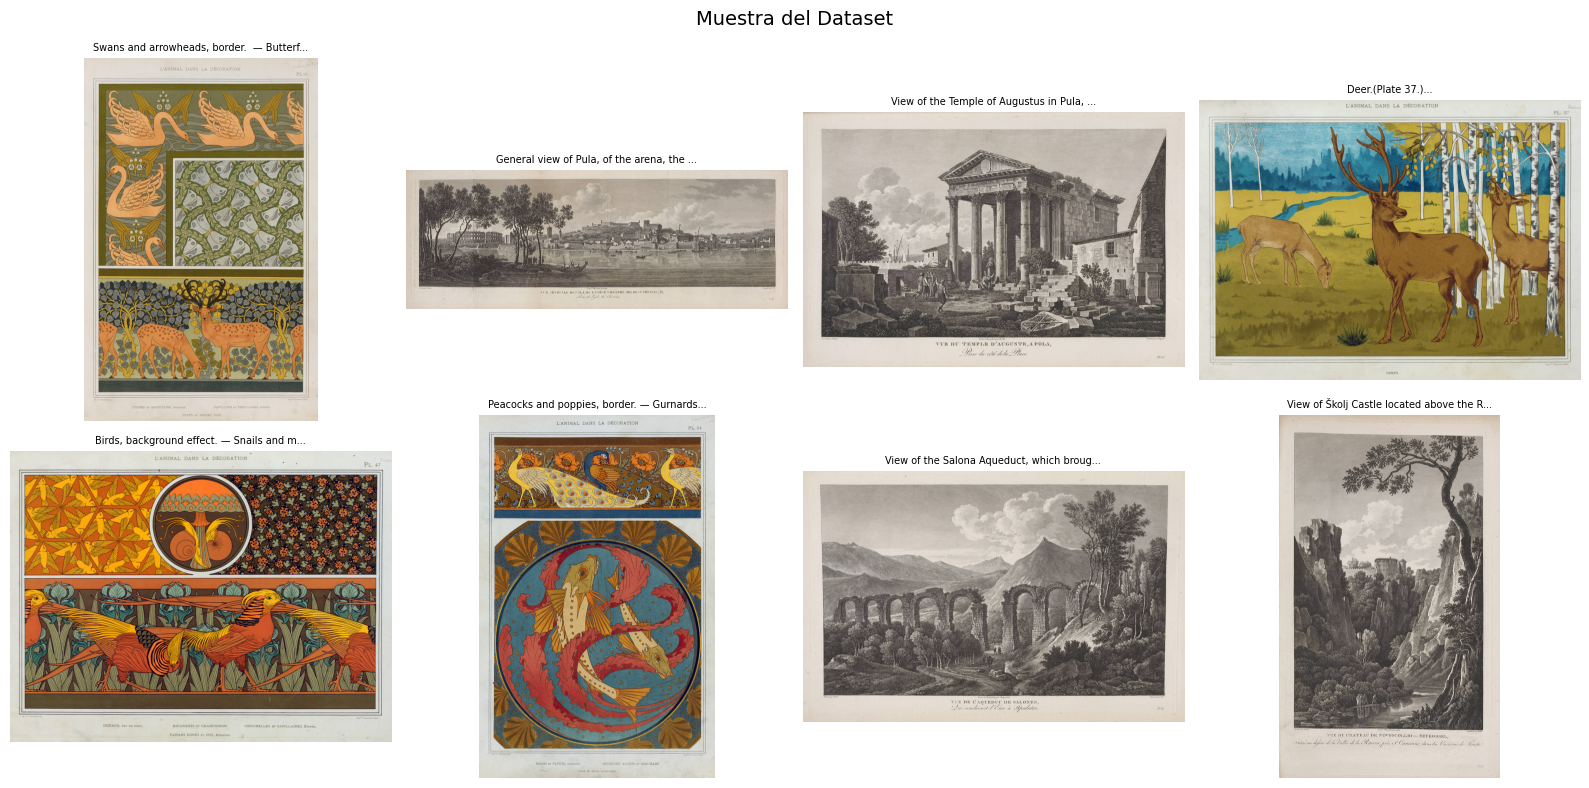

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flatten()):
    row = data.iloc[i]
    try:
        img = Image.open(row["image_path"])
        ax.imshow(img)
        ax.set_title(row["caption"][:40] + "...", fontsize=7)
        ax.axis("off")
    except Exception as e:
        ax.set_title(f"Error: {e}", fontsize=7)
        ax.axis("off")

plt.suptitle("Muestra del Dataset", fontsize=14)
plt.tight_layout()
plt.show()

Los datos están bien cargados. Comienzo el EDA

In [6]:
print(f"Shape: {data.shape}")
print(f"\nTipos:\n{data.dtypes}")
print(f"\nNulos:\n{data.isnull().sum()}")

Shape: (4198, 7)

Tipos:
id               int64
artist_name     object
caption         object
url             object
description     object
image_path      object
image_exists      bool
dtype: object

Nulos:
id                0
artist_name       1
caption           0
url               0
description     104
image_path        0
image_exists      0
dtype: int64


Debido a la naturaleza artistica del dataset y que es un proyecto personal, voy a priorizar la precisión del modelo frente a la cantidad de autores.

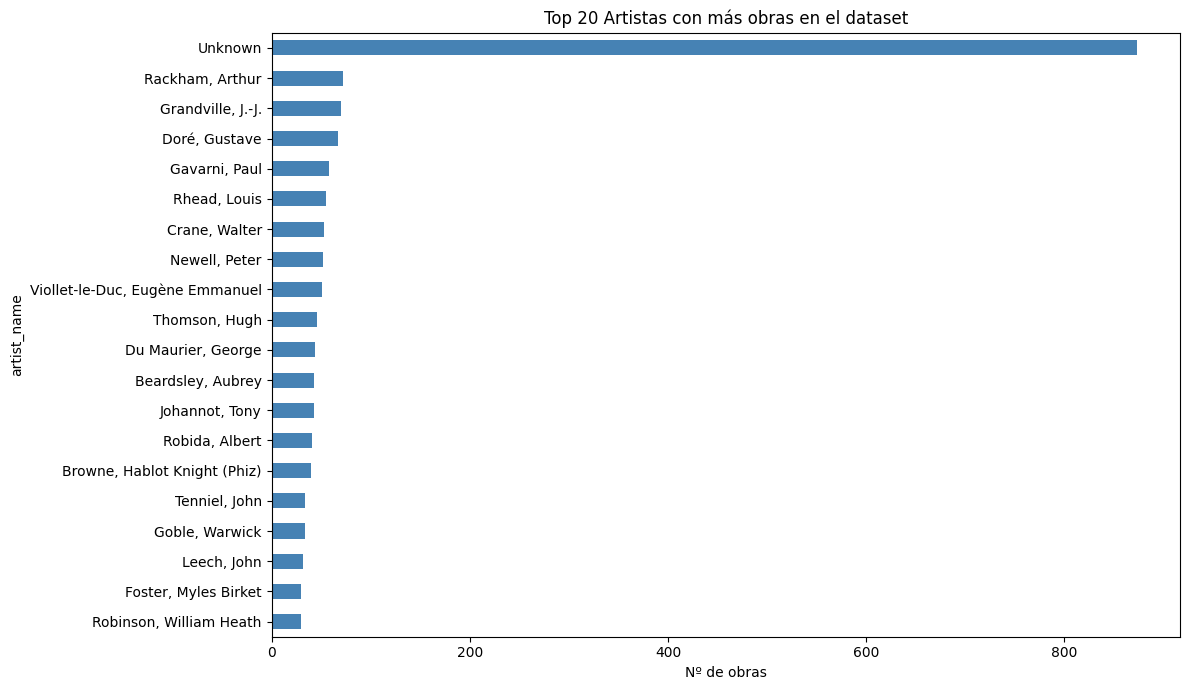


Total artistas únicos: 491
Artista con más obras: Unknown (873 obras)


In [7]:
# Top 20 artistas con más obras
top_artists = data["artist_name"].value_counts().head(20)

plt.figure(figsize=(12, 7))
top_artists.plot(kind="barh", color="steelblue")
plt.title("Top 20 Artistas con más obras en el dataset")
plt.xlabel("Nº de obras")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal artistas únicos: {data['artist_name'].nunique()}")
print(f"Artista con más obras: {top_artists.index[0]} ({top_artists.iloc[0]} obras)")

In [8]:
n_unknown = (data["artist_name"] == "Unknown").sum()
n_known   = (data["artist_name"] != "Unknown").sum()

print(f"Unknown  : {n_unknown} ({n_unknown/len(data)*100:.1f}%)")
print(f"Con autor: {n_known}  ({n_known/len(data)*100:.1f}%)")

Unknown  : 873 (20.8%)
Con autor: 3325  (79.2%)


El dataset tiene una buena calidad, sigo pudiendo trabajar con 3 mil imagenes

In [9]:
#Elimino los artistas desconocidos
data_known = data[data["artist_name"] != "Unknown"].copy()
print(f"Dataset limpio: {len(data_known)} imágenes")
print(f"Artistas únicos: {data_known['artist_name'].nunique()}")

Dataset limpio: 3325 imágenes
Artistas únicos: 490


In [10]:
#VEamos ahora que artistas tienen más obras en el dataset limpio
obras_por_artista = data_known["artist_name"].value_counts()

print(f"Artistas con más de 50 obras : {(obras_por_artista >= 50).sum()}")
print(f"Artistas con más de 20 obras : {(obras_por_artista >= 20).sum()}")
print(f"Artistas con solo 1 obra     : {(obras_por_artista == 1).sum()}")

Artistas con más de 50 obras : 8
Artistas con más de 20 obras : 34
Artistas con solo 1 obra     : 167


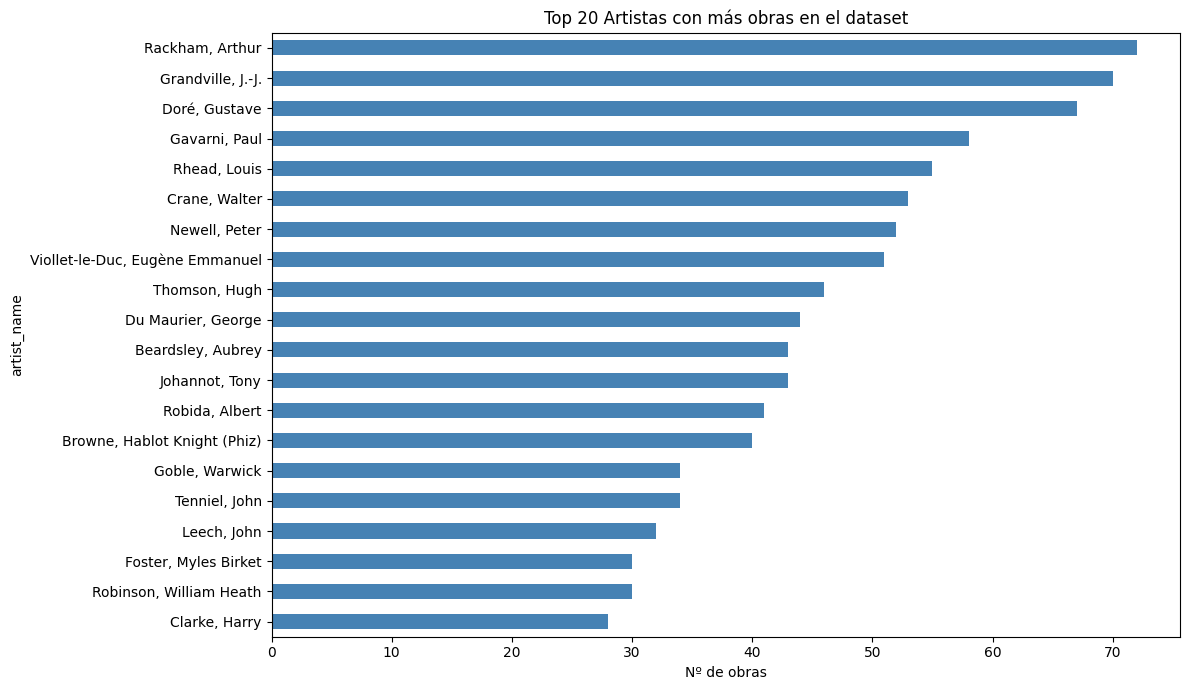


Total artistas únicos: 490
Artista con más obras: Rackham, Arthur (72 obras)


In [11]:
top_artists = data_known["artist_name"].value_counts().head(20)

plt.figure(figsize=(12, 7))
top_artists.plot(kind="barh", color="steelblue")
plt.title("Top 20 Artistas con más obras en el dataset")
plt.xlabel("Nº de obras")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal artistas únicos: {data_known['artist_name'].nunique()}")
print(f"Artista con más obras: {top_artists.index[0]} ({top_artists.iloc[0]} obras)")

Voy a ver si hay descripciones vacias

In [12]:
# Ver todos los valores problemáticos en description
print("=== VALORES VACÍOS / UNKNOWN EN DESCRIPTION ===")
print(f"Nulos            : {data['description'].isnull().sum()}")
print(f"String vacío ''  : {(data['description'] == '').sum()}")
print(f"'Unknown'        : {(data['description'].str.lower() == 'unknown').sum()}")
print(f"'N/A' o similar  : {(data['description'].str.lower().isin(['n/a','na','none','-'])).sum()}")
print(f"\nTotal filas antes: {len(data)}")

=== VALORES VACÍOS / UNKNOWN EN DESCRIPTION ===
Nulos            : 104
String vacío ''  : 0
'Unknown'        : 0
'N/A' o similar  : 0

Total filas antes: 4198


In [13]:
# Eliminar filas con description vacía o desconocida
mask_invalid = (
    data["description"].isnull() |
    (data["description"].str.strip() == "") |
    (data["description"].str.lower().isin(["unknown", "n/a", "na", "none", "-"]))
)

data_clean = data[~mask_invalid].copy()
print(f"Filas eliminadas : {mask_invalid.sum()}")
print(f"Filas restantes  : {len(data_clean)}")

Filas eliminadas : 104
Filas restantes  : 4094


Voy a crear un dataset limpio y a trabajar coon él, solo trabajaré artistas con mas de 10 cuadros

In [14]:
# Quedarse solo con artistas conocidos y con suficientes obras
MIN_OBRAS = 10  # umbral mínimo

obras = data_clean[data_clean["artist_name"] != "Unknown"]["artist_name"].value_counts()
artistas_validos = obras[obras >= MIN_OBRAS].index

data_model = data_clean[data_clean["artist_name"].isin(artistas_validos)].copy()

print(f"Artistas válidos (>= {MIN_OBRAS} obras): {len(artistas_validos)}")
print(f"Imágenes para el modelo              : {len(data_model)}")
print(f"\nDistribución:\n{data_model['artist_name'].value_counts()}")

Artistas válidos (>= 10 obras): 94
Imágenes para el modelo              : 2049

Distribución:
artist_name
Rackham, Arthur             72
Grandville, J.-J.           70
Doré, Gustave               67
Gavarni, Paul               58
Rhead, Louis                55
                            ..
Mackenzie, Frederick        10
Metcalfe, Gerald Fenwick    10
Norman                      10
Forestier, Amédée           10
Lalauze, Adolphe            10
Name: count, Length: 94, dtype: int64


El modelo necesita mas de 10 imagenes, debido a que los 5 autores con mas obras cuentan con mas de 5o me centraré en ellos

In [15]:
TOP_N = 5  #Cambiar este numero para probar con más o menos artistas

top_artistas = data_model["artist_name"].value_counts().head(TOP_N).index
data_final = data_model[data_model["artist_name"].isin(top_artistas)].copy()

print(f"Artistas: {data_final['artist_name'].nunique()}")
print(f"Imágenes: {len(data_final)}")
print(f"\nDistribución:\n{data_final['artist_name'].value_counts()}")

Artistas: 5
Imágenes: 322

Distribución:
artist_name
Rackham, Arthur      72
Grandville, J.-J.    70
Doré, Gustave        67
Gavarni, Paul        58
Rhead, Louis         55
Name: count, dtype: int64


In [16]:
# Combinar caption + description como texto de entrada
data_final["texto"] = data_final["caption"] + " " + data_final["description"]

# Etiquetas numéricas
le = LabelEncoder()
data_final["label"] = le.fit_transform(data_final["artist_name"])

print(f"Clases: {list(le.classes_)}")

Clases: ['Doré, Gustave', 'Gavarni, Paul', 'Grandville, J.-J.', 'Rackham, Arthur', 'Rhead, Louis']


In [17]:
X = data_final["texto"]
y = data_final["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 257 | Test: 65


In [18]:
pipelines = {
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=500, ngram_range=(1,2), sublinear_tf=True)),
        ("clf",   LogisticRegression(max_iter=1000, C=1.0, random_state=42))
    ]),
    "Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=500, ngram_range=(1,2), sublinear_tf=True)),
        ("clf",   LinearSVC(max_iter=2000, C=0.5, random_state=42))
    ]),
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=500, ngram_range=(1,2))),
        ("clf",   MultinomialNB(alpha=0.5))
    ])
}

resultados = {}
print(f"{'Modelo':<25} {'CV Accuracy':<20} {'Test Accuracy'}")
print("-" * 60)

for nombre, pipeline in pipelines.items():
    cv = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
    pipeline.fit(X_train, y_train)
    test_acc = pipeline.score(X_test, y_test)
    resultados[nombre] = {"cv": cv.mean(), "std": cv.std(), "test": test_acc}
    print(f"{nombre:<25} {cv.mean():.4f} ± {cv.std():.4f}    {test_acc:.4f}")

Modelo                    CV Accuracy          Test Accuracy
------------------------------------------------------------
Logistic Regression       0.6928 ± 0.0312    0.7385
Linear SVM                0.7085 ± 0.0609    0.7692
Naive Bayes               0.7086 ± 0.0526    0.7538


In [19]:
mejor = max(resultados, key=lambda k: resultados[k]["test"])
print(f"\n Mejor modelo: {mejor} ({resultados[mejor]['test']:.4f})\n")

y_pred = pipelines[mejor].predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))


 Mejor modelo: Linear SVM (0.7692)

                   precision    recall  f1-score   support

    Doré, Gustave       0.88      0.54      0.67        13
    Gavarni, Paul       0.92      0.92      0.92        12
Grandville, J.-J.       0.72      0.93      0.81        14
  Rackham, Arthur       0.62      0.87      0.72        15
     Rhead, Louis       1.00      0.55      0.71        11

         accuracy                           0.77        65
        macro avg       0.83      0.76      0.76        65
     weighted avg       0.81      0.77      0.76        65



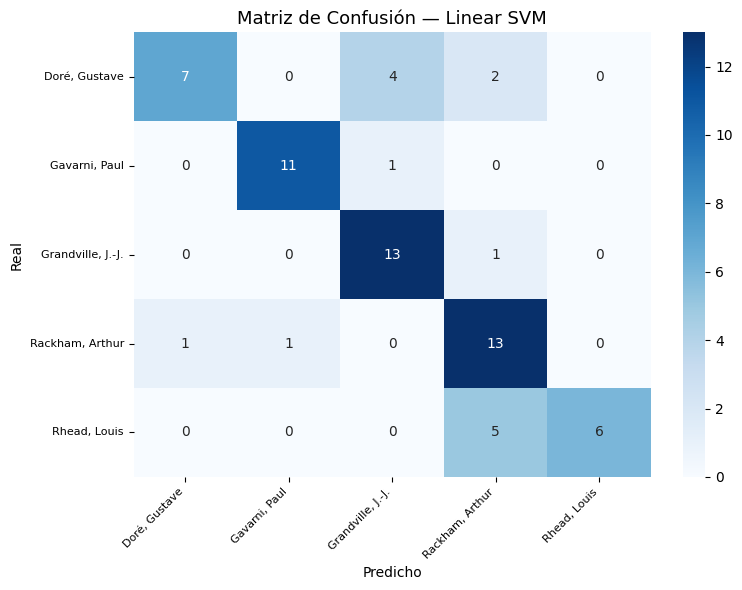

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.title(f"Matriz de Confusión — {mejor}", fontsize=13)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

CONCLUSIÓN
EL arte humano es dificil de entender por modelos de IA y mas si es de un mismo estilo, incluso con 70 obras hay un rango de error del 30%.